<a href="https://colab.research.google.com/github/vivekbelwal17/sentifilm/blob/main/capston_riviewsentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ========================================================
# Sentiment Analysis using LSTM on IMDB Movie Reviews
# Using Keras Built-in Dataset - Clean & Simple Version
# ========================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
# ====================== Hyperparameters ======================
MAX_FEATURES = 15000    # Vocabulary size
MAX_LEN = 300          # Maximum review length
EMBEDDING_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 32
EPOCHS = 8

In [ ]:
print("Loading IMDB dataset...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

print("Padding sequences to fixed length...")
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Padding sequences to fixed length...


In [ ]:

print(f"After padding → Train shape: {x_train.shape}")
print(f"After padding → Test shape : {x_test.shape}\n")

After padding → Train shape: (25000, 300)
After padding → Test shape : (25000, 300)



In [ ]:
# ====================== 3. Build LSTM Model ======================
model = Sequential()

model.add(Embedding(input_dim=MAX_FEATURES,
                    output_dim=EMBEDDING_DIM,
                    input_length=MAX_LEN))

model.add(LSTM(units=LSTM_UNITS,
               dropout=0.2,
               recurrent_dropout=0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model Summary:")
model.summary()

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ====================== 4. Callbacks ======================
checkpoint = ModelCheckpoint(
    filepath='models/LSTM_IMDB.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# ====================== 5. Train the Model ======================
print("\nStarting Training...\n")
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.2,
                    callbacks=[checkpoint, early_stop],
                    verbose=1)


Starting Training...

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.7090 - loss: 0.5576
Epoch 1: val_accuracy improved from None to 0.78140, saving model to models/LSTM_IMDB.h5



Epoch 1: finished saving model to models/LSTM_IMDB.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 522s 828ms/step - accuracy: 0.7666 - loss: 0.4915 - val_accuracy: 0.7814 - val_loss: 0.4499
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.8591 - loss: 0.3549
Epoch 2: val_accuracy improved from 0.78140 to 0.83700, saving model to models/LSTM_IMDB.h5



Epoch 2: finished saving model to models/LSTM_IMDB.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 560s 826ms/step - accuracy: 0.8617 - loss: 0.3421 - val_accuracy: 0.8370 - val_loss: 0.3736
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.9070 - loss: 0.2434
Epoch 3: val_accuracy did not improve from 0.83700
625/625 ━━━━━━━━━━━━━━━━━━━━ 561s 825ms/step - accuracy: 0.9014 - loss: 0.2504 - val_accuracy: 0.8370 - val_loss: 0.3917
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9330 - loss: 0.1862
Epoch 4: val_accuracy improved from 0.83700 to 0.86380, saving model to models/LSTM_IMDB.h5



Epoch 4: finished saving model to models/LSTM_IMDB.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 516s 825ms/step - accuracy: 0.9330 - loss: 0.1840 - val_accuracy: 0.8638 - val_loss: 0.3700
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9526 - loss: 0.1351
Epoch 5: val_accuracy did not improve from 0.86380
625/625 ━━━━━━━━━━━━━━━━━━━━ 563s 827ms/step - accuracy: 0.9518 - loss: 0.1384 - val_accuracy: 0.8486 - val_loss: 0.4483
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.9571 - loss: 0.1155
Epoch 6: val_accuracy did not improve from 0.86380
625/625 ━━━━━━━━━━━━━━━━━━━━ 514s 821ms/step - accuracy: 0.9580 - loss: 0.1136 - val_accuracy: 0.8508 - val_loss: 0.5202
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.9743 - loss: 0.0748
Epoch 7: val_accuracy did not improve from 0.86380
625/625 ━━━━━━━━━━━━━━━━━━━━ 514s 822ms/step - accuracy: 0.9739 - loss: 0.0771 - val_accuracy: 0.8484 - val_loss: 0.5323
Epoch 7: early stopping
Restoring model weights

In [ ]:
# ====================== 6. Evaluate on Test Set ======================
print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")



Evaluating on Test Data...
Test Accuracy: 85.82%
Test Loss    : 0.3839


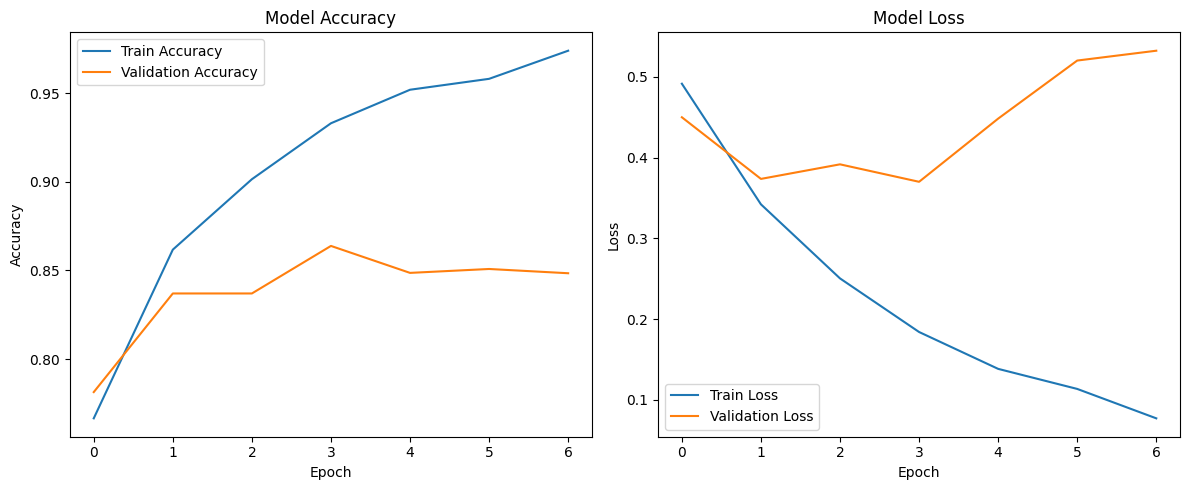

In [ ]:
# ====================== 7. Plot Training History ======================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ====================== 8. Custom Review Prediction Function ======================
def predict_sentiment(review_text):
    word_index = imdb.get_word_index()
    # Convert text to sequence of indices
    tokens = [word_index.get(word, 0) for word in review_text.lower().split()]
    # Pad the sequence
    padded = pad_sequences([tokens], maxlen=MAX_LEN)

    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"

    return sentiment, round(prediction, 4)

In [ ]:
# ====================== 9. Test with Custom Reviews ======================
print("\n" + "="*60)
print("CUSTOM MOVIE REVIEW ANALYZER")
print("="*60)

# 1. First, run the existing hardcoded tests
test_reviews = [
    "This movie was absolutely fantastic with brilliant acting and story!",
    "Worst movie I have ever seen. Complete waste of time and money."
]

for i, review in enumerate(test_reviews, 1):
    sentiment, confidence = predict_sentiment(review)
    print(f"Test {i}: {sentiment} ({confidence})")

print("-" * 50)

# 2. NOW: Choose your own movie review
print("\n>>> YOUR TURN:")
user_review = input("Paste a movie review here and press Enter: ")

if user_review:
    sentiment, confidence = predict_sentiment(user_review)
    print(f"\nYour Review Analysis:")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence Score: {confidence}")

# Optional: Save final model
import os
if not os.path.exists('models'):
    os.makedirs('models')
model.save('models/Final_LSTM_IMDB_Model.h5')
print("\nModel saved successfully as 'Final_LSTM_IMDB_Model.h5'")


CUSTOM MOVIE REVIEW ANALYZER
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Test 1: Negative (0.21610000729560852)
Test 2: Negative (0.4404999911785126)
--------------------------------------------------

>>> YOUR TURN:
Paste a movie review here and press Enter: A great return that is just as sharp and stylish as the original. The struggle between the characters is great to see, proving they still have plenty of power years later. It is a great film of ambition and fashion that is meant to be seen.



Your Review Analysis:
Predicted Sentiment: Positive
Confidence Score: 0.8549000024795532

Model saved successfully as 'Final_LSTM_IMDB_Model.h5'
